In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("final_ev_dataset_15000.csv")

df.head()

,state,City,Two Wheeler,Three Wheeler,Four Wheeler,Goods Vehicles,Public Service Vehicle,Special Category Vehicles,Ambulance/Hearses,Construction Equipment Vehicle,...,Power (kW),station_id,location,charging_type,num_chargers,voltage_level,current_flow,power_consumed,power_loss,voltage_fluctuation
0,Dadra and Nagar Haveli and Daman and Diu,Daman,17110,47421,12945,6001,7350,6129,33265,20286,...,137,1,Rural,Ultra Fast,46,440.13,244.72,107.71,10.47,2.28
1,Chhattisgarh,Bhilai,23061,25198,10893,33940,633,7394,19824,41385,...,104,2,Highway,Slow,16,767.28,42.89,32.91,2.65,8.23
2,Haryana,Gurgaon,43369,17380,14479,21884,3957,21540,27705,6706,...,207,3,Rural,Slow,46,594.42,466.06,277.04,12.76,2.31
3,Rajasthan,Jaipur,43509,38373,16327,8519,25638,40594,24737,13692,...,57,4,Rural,Slow,9,236.13,311.65,73.59,4.98,2.08
4,Rajasthan,Udaipur,3019,338,46312,17748,24695,23175,25536,13340,...,96,5,Rural,Ultra Fast,49,537.57,488.87,262.80,14.48,13.59


In [4]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())

(15000, 24)
Index(['state', 'City', 'Two Wheeler', 'Three Wheeler', 'Four Wheeler',
       'Goods Vehicles', 'Public Service Vehicle', 'Special Category Vehicles',
       'Ambulance/Hearses', 'Construction Equipment Vehicle', 'Station Name',
       'Operator', 'Usage Type', 'Connector Type', 'Power (kW)', 'station_id',
       'location', 'charging_type', 'num_chargers', 'voltage_level',
       'current_flow', 'power_consumed', 'power_loss', 'voltage_fluctuation'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   state                           15000 non-null  str    
 1   City                            15000 non-null  str    
 2   Two Wheeler                     15000 non-null  int64  
 3   Three Wheeler                   15000 non-null  int64  
 4   Four Wheeler                    15000 non-n

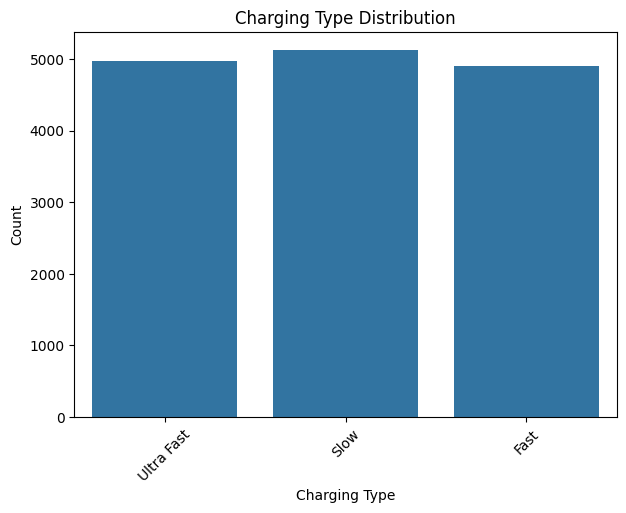

In [5]:
plt.figure(figsize=(7,5))
sns.countplot(x='charging_type', data=df)

plt.title("Charging Type Distribution")
plt.xlabel("Charging Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

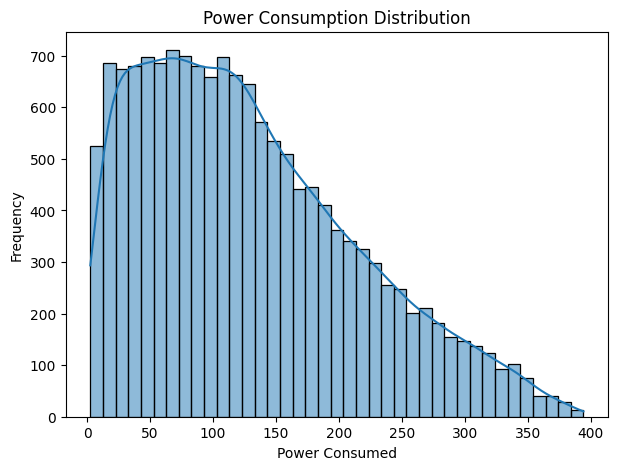

In [6]:
plt.figure(figsize=(7,5))
sns.histplot(df['power_consumed'], kde=True)

plt.title("Power Consumption Distribution")
plt.xlabel("Power Consumed")
plt.ylabel("Frequency")

plt.show()

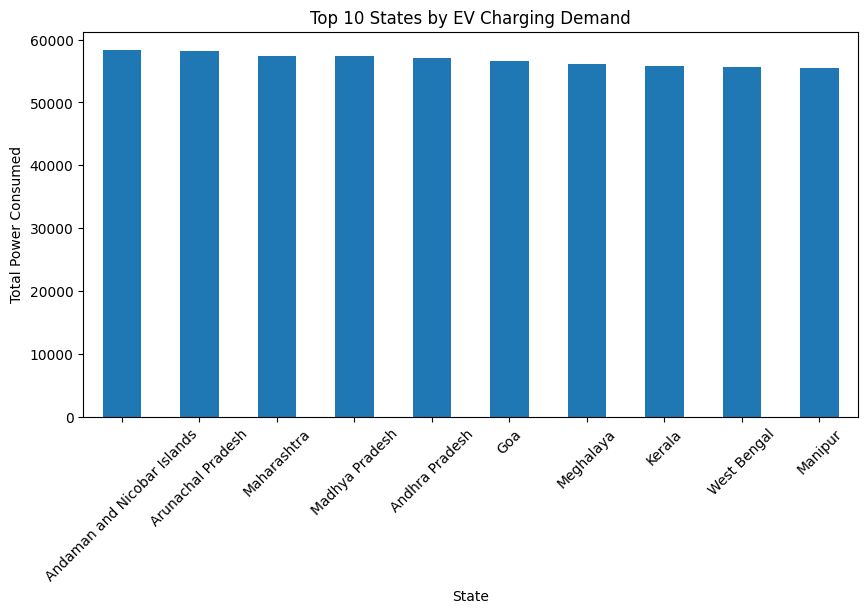

In [7]:
top_states = df.groupby('state')['power_consumed'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar')

plt.title("Top 10 States by EV Charging Demand")
plt.xlabel("State")
plt.ylabel("Total Power Consumed")
plt.xticks(rotation=45)

plt.show()

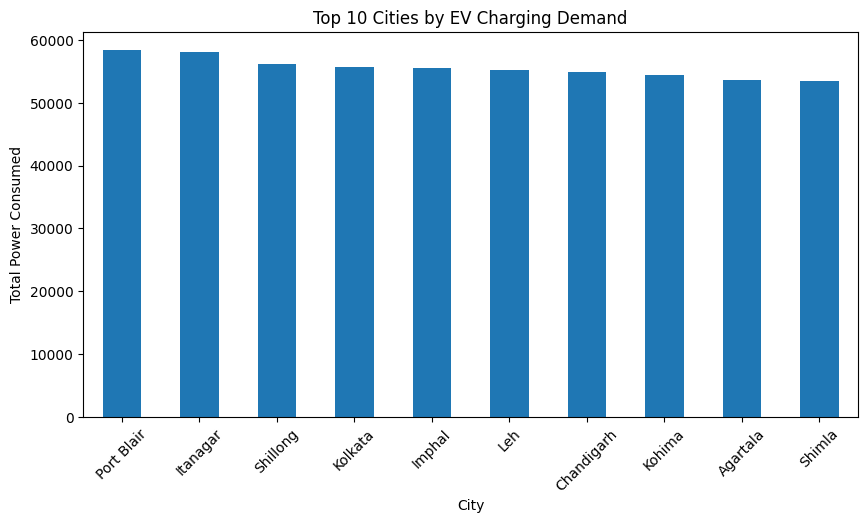

In [8]:
top_cities = df.groupby('City')['power_consumed'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')

plt.title("Top 10 Cities by EV Charging Demand")
plt.xlabel("City")
plt.ylabel("Total Power Consumed")
plt.xticks(rotation=45)

plt.show()

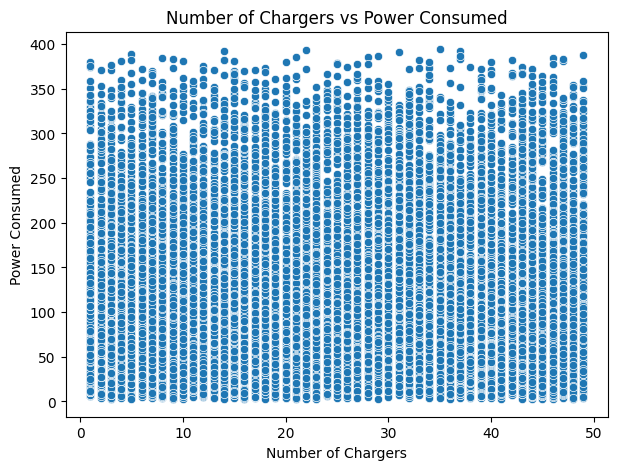

In [9]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='num_chargers', y='power_consumed', data=df)

plt.title("Number of Chargers vs Power Consumed")
plt.xlabel("Number of Chargers")
plt.ylabel("Power Consumed")

plt.show()

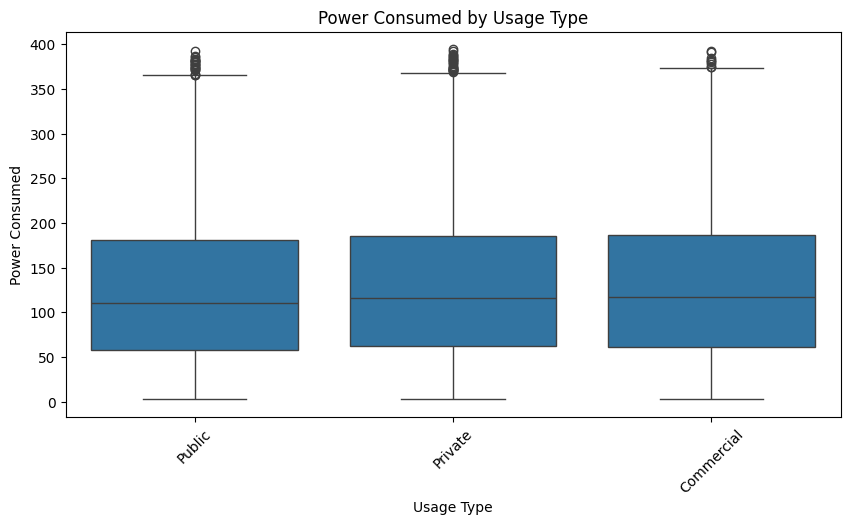

In [10]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Usage Type', y='power_consumed', data=df)

plt.title("Power Consumed by Usage Type")
plt.xlabel("Usage Type")
plt.ylabel("Power Consumed")
plt.xticks(rotation=45)

plt.show()

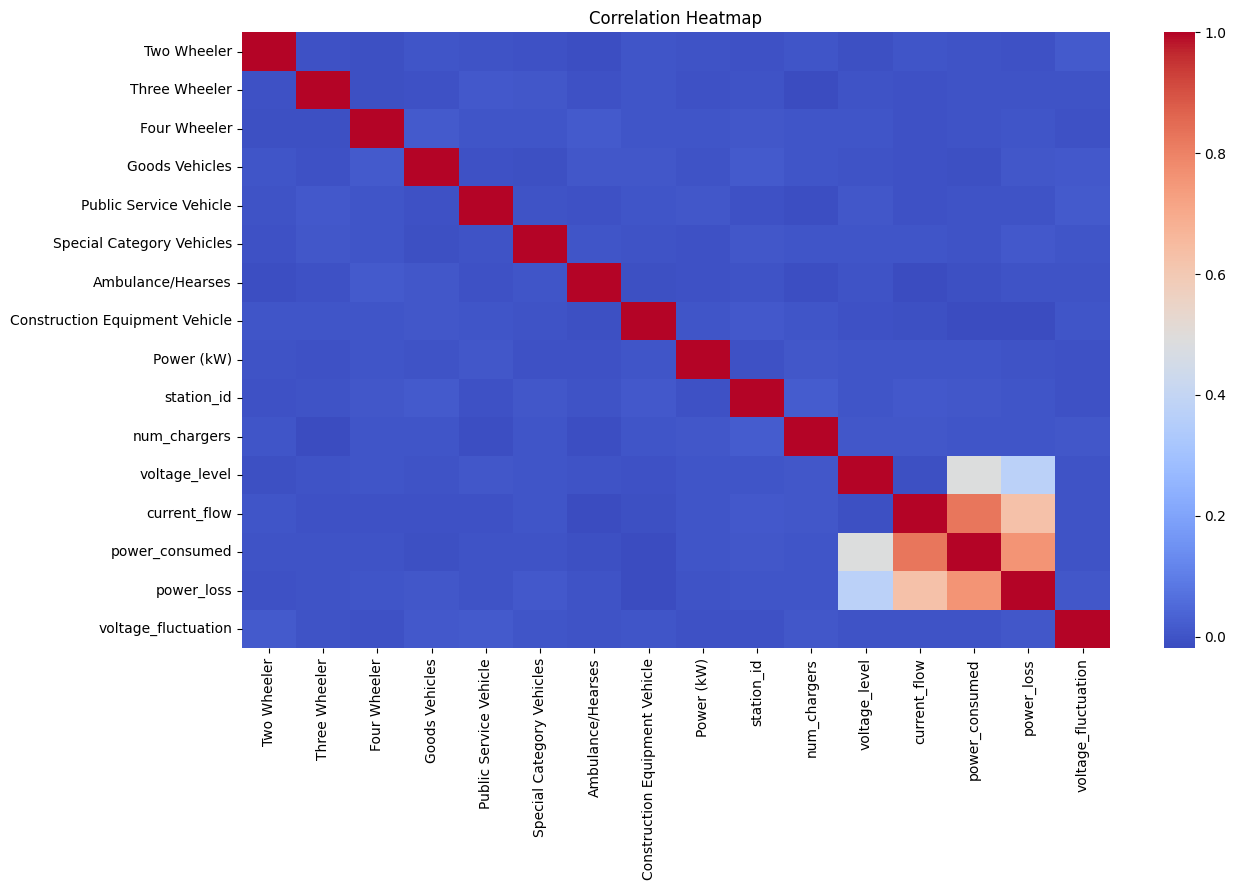

In [11]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(14,8))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

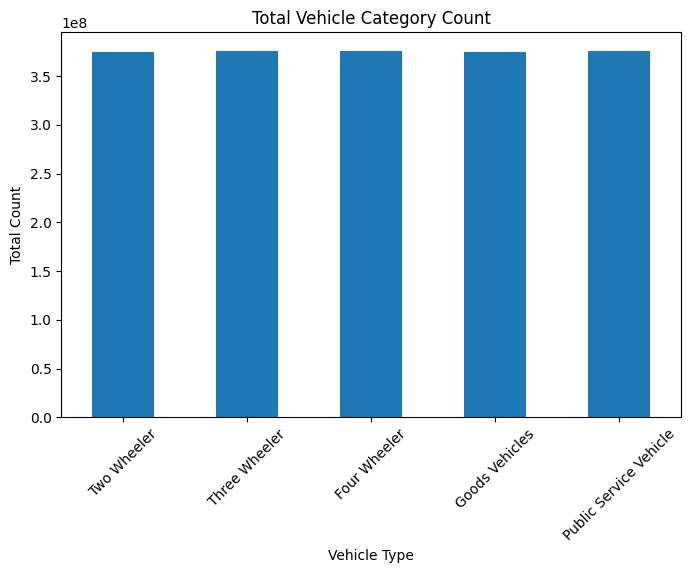

In [12]:
vehicle_cols = [
    'Two Wheeler',
    'Three Wheeler',
    'Four Wheeler',
    'Goods Vehicles',
    'Public Service Vehicle'
]

vehicle_sum = df[vehicle_cols].sum()

plt.figure(figsize=(8,5))
vehicle_sum.plot(kind='bar')

plt.title("Total Vehicle Category Count")
plt.xlabel("Vehicle Type")
plt.ylabel("Total Count")
plt.xticks(rotation=45)

plt.show()

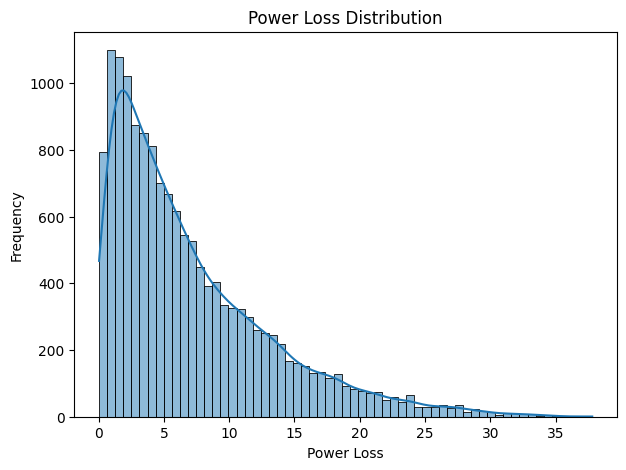

In [13]:
plt.figure(figsize=(7,5))
sns.histplot(df['power_loss'], kde=True)

plt.title("Power Loss Distribution")
plt.xlabel("Power Loss")
plt.ylabel("Frequency")

plt.show()